# CNN para clasificación de **cáncer de piel** (9 clases, ISIC) — Notebook Base

**Propósito educativo**: entrenar un modelo de visión (CNN/Transfer Learning) para clasificar **9 clases** del dataset ISIC de cáncer de piel. **No es un dispositivo médico** ni debe usarse para diagnóstico clínico.

**Dataset**: [Kaggle: Skin Cancer 9 Classes (ISIC)](https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic)

---
### Objetivos
1. Descargar y preparar el dataset en formato directorios por clase.
2. Construir un baseline CNN y un modelo de **Transfer Learning** (EfficientNet/MobileNet).
3. Entrenar y evaluar con métricas **multiclase** (accuracy, macro-F1, balanced accuracy).
4. Visualizar curvas de entrenamiento y **matriz de confusión**.
5. Guardar el mejor modelo.

### Clases (pueden variar según el dataset):
- actinic_keratosis, basal_cell_carcinoma, dermatofibroma, melanoma, nevus, pigmented_benign_keratosis, seborrheic_keratosis, squamous_cell_carcinoma, vascular_lesion


In [ ]:
# Instalación de paquetes necesarios
#!pip -q install kaggle tensorflow scikit-learn matplotlib seaborn pandas Pillow


## 1. Configuración y librerías
- Verificar GPU.
- Fijar semillas.
- Importar librerías.


In [ ]:
import os, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)} ->', gpus)

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 10


GPUs disponibles: 0 -> []


## 2. Descarga del dataset (Kaggle) y estructura de carpetas
- Requiere `~/.kaggle/kaggle.json`.
- Alternativa: descarga manual desde kaggle, se bajará el archivo archive.zip, subelo a este drive y descomprime en `data/`.


In [ ]:
import zipfile
import os

zip_file = 'archive.zip'
extract_dir = '/content/data'

if os.path.exists(zip_file):
    print(f"El archivo '{zip_file}' existe.")
else:
    print(f"El archivo '{zip_file}' no existe.")

os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)



El archivo 'archive.zip' existe.


In [ ]:
DATA_ROOT = '/content/data/Skin cancer ISIC The International Skin Imaging Collaboration'
os.makedirs(DATA_ROOT, exist_ok=True)

# Descarga vía API (descomentar)
# from kaggle import api
# api.dataset_download_files('nodoubttome/skin-cancer9-classesisic', path=DATA_ROOT, unzip=True)

# Intento de auto-descubrir splits
def find_split_dirs(root='data'):
    cands = []
    for dirpath, dirnames, filenames in os.walk(root):
        b = os.path.basename(dirpath).lower()
        if b in ['train', 'training', 'test', 'validation', 'val']:
            cands.append(dirpath)
    return cands

cands = find_split_dirs(DATA_ROOT)
print('Posibles splits:', cands)
TRAIN_DIR = None; VAL_DIR = None; TEST_DIR = None
for p in cands:
    b = os.path.basename(p).lower()
    if b == 'train': TRAIN_DIR = p
    elif b in ['validation','val']: VAL_DIR = p
    elif b == 'test': TEST_DIR = p
print('TRAIN_DIR:', TRAIN_DIR)
print('VAL_DIR:', VAL_DIR)
print('TEST_DIR:', TEST_DIR)
USE_VALIDATION_SPLIT = VAL_DIR is None
print('Usar validation_split desde TRAIN_DIR:', USE_VALIDATION_SPLIT)


Posibles splits: ['/content/data/Skin cancer ISIC The International Skin Imaging Collaboration/Train', '/content/data/Skin cancer ISIC The International Skin Imaging Collaboration/Test']
TRAIN_DIR: /content/data/Skin cancer ISIC The International Skin Imaging Collaboration/Train
VAL_DIR: None
TEST_DIR: /content/data/Skin cancer ISIC The International Skin Imaging Collaboration/Test
Usar validation_split desde TRAIN_DIR: True


## 3. Exploración rápida
- Recuento de imágenes por clase.
- Muestras por clase.


Recuento en TRAIN: {'actinic keratosis': 114, 'basal cell carcinoma': 376, 'dermatofibroma': 95, 'melanoma': 438, 'nevus': 357, 'pigmented benign keratosis': 462, 'seborrheic keratosis': 77, 'squamous cell carcinoma': 181, 'vascular lesion': 139}


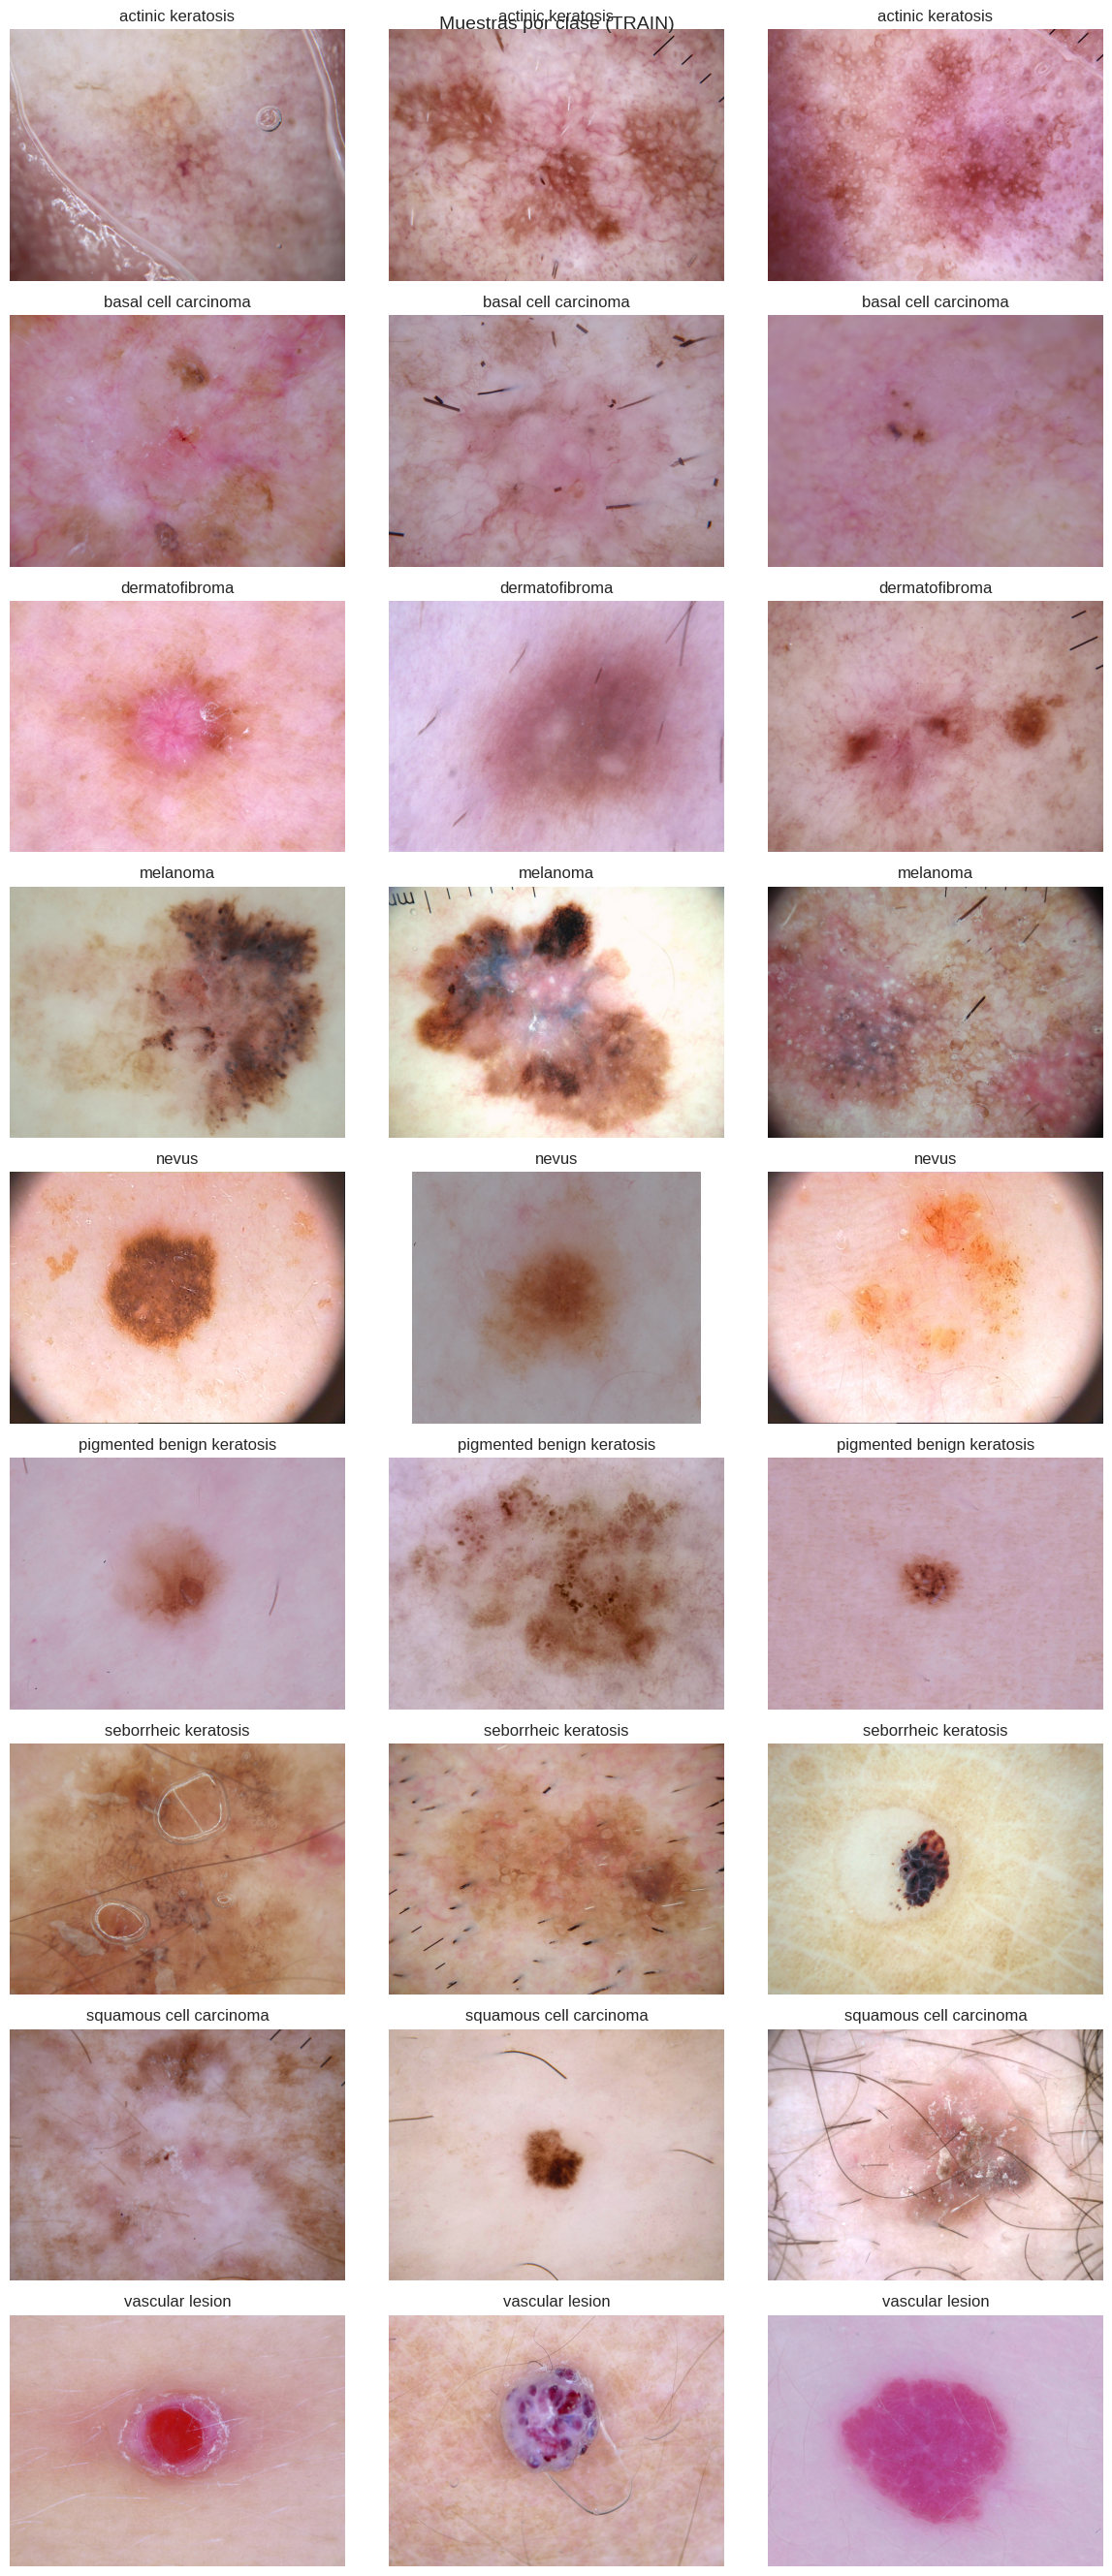

In [ ]:
def count_images_by_class(split_dir):
    if not split_dir or not os.path.isdir(split_dir):
        return {}
    counts = {}
    for cls in sorted([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]):
        n = len(glob.glob(os.path.join(split_dir, cls, '**', '*.*'), recursive=True))
        counts[cls] = n
    return counts

train_counts = count_images_by_class(TRAIN_DIR)
print('Recuento en TRAIN:', train_counts)

# Visualización de ejemplos
def show_samples_by_class(split_dir, n_per_class=3):
    if not split_dir: return
    classes = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    cols = min(3, n_per_class)
    rows = len(classes)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    if rows == 1: axes = np.array([axes])
    for r, cls in enumerate(sorted(classes)):
        imgs = glob.glob(os.path.join(split_dir, cls, '*'))
        random.shuffle(imgs)
        for c in range(cols):
            ax = axes[r][c] if rows>1 else axes[c]
            if c < len(imgs):
                ax.imshow(Image.open(imgs[c]))
                ax.axis('off')
                ax.set_title(cls)
            else:
                ax.axis('off')
    fig.suptitle('Muestras por clase (TRAIN)', fontsize=14)
    plt.tight_layout()

show_samples_by_class(TRAIN_DIR, n_per_class=3)


## 4. Generadores y aumento de datos
- Redimensiona a 224×224 (RGB).
- Normaliza y aplica augmentations.


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
COLOR_MODE = 'rgb'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2 if USE_VALIDATION_SPLIT else 0.0
)

if TRAIN_DIR:
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        color_mode=COLOR_MODE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training' if USE_VALIDATION_SPLIT else None,
        seed=SEED
    )

    if USE_VALIDATION_SPLIT:
        val_gen = train_datagen.flow_from_directory(
            TRAIN_DIR,
            target_size=IMG_SIZE,
            color_mode=COLOR_MODE,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            subset='validation',
            seed=SEED
        )
    elif VAL_DIR:
        val_datagen = ImageDataGenerator(rescale=1./255)
        val_gen = val_datagen.flow_from_directory(
            VAL_DIR,
            target_size=IMG_SIZE,
            color_mode=COLOR_MODE,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            seed=SEED
        )
else:
    train_gen, val_gen = None, None

# Test generator
if TEST_DIR:
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        color_mode=COLOR_MODE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
else:
    test_gen = None

print('Clases:', getattr(train_gen, 'class_indices', None))
NUM_CLASSES = len(getattr(train_gen, 'class_indices', {})) if train_gen else 9


Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Found 118 images belonging to 9 classes.
Clases: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


## 5. Modelos
### 5.1 Baseline CNN (desde cero)


In [ ]:
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)

def build_cnn_baseline(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline = build_cnn_baseline(input_shape, NUM_CLASSES)
baseline.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,465 (1.75 MB)

 Trainable params: 457,993 (1.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
baseline.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,465 (1.75 MB)

 Trainable params: 457,993 (1.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

### 5.2 Transfer Learning (EfficientNetB0)
- Congelar base y entrenar cabeza densa.
- Opcional: *fine-tuning* de bloques superiores.


In [ ]:
def build_efficientnet(input_shape, num_classes):
    base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                                input_shape=input_shape)
    base.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

efficient = build_efficientnet(input_shape, NUM_CLASSES)
efficient.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
if train_gen:
  print("test_gen")

## 6. Entrenamiento
- Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau.
- Entrenar baseline y/o EfficientNet (elige uno).


In [ ]:
EPOCHS = 20
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('mejor_modelo_skin_isic.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
]

history = None
if train_gen and val_gen:
    # Escoge el modelo a entrenar: baseline o efficient
    model = efficient  # cambia a 'baseline' si deseas el modelo desde cero
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=callbacks)
else:
    print('Generadores de entrenamiento/validación no configurados.')


Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1870 - loss: 2.1068

57/57 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - accuracy: 0.1961 - loss: 2.0810 - val_accuracy: 0.1959 - val_loss: 2.0372 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1838 - loss: 2.0695

57/57 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.1922 - loss: 2.0570 - val_accuracy: 0.1959 - val_loss: 2.0306 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.1850 - loss: 2.0602 - val_accuracy: 0.1599 - val_loss: 2.0394 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1977 - loss: 2.0585

57/57 ━━━━━━━━━━━━━━━━━━━━ 212s 4s/step - accuracy: 0.1883 - loss: 2.0688 - val_accuracy: 0.2072 - val_loss: 2.0277 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2102 - loss: 2.0371

57/57 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.2022 - loss: 2.0456 - val_accuracy: 0.2072 - val_loss: 2.0223 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1695 - loss: 2.0725

...

57/57 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.1861 - loss: 2.0400 - val_accuracy: 0.2072 - val_loss: 2.0155 - learning_rate: 5.0000e-04
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 207s 4s/step - accuracy: 0.1827 - loss: 2.0462 - val_accuracy: 0.1959 - val_loss: 2.0229 - learning_rate: 5.0000e-04
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.2072 - loss: 2.0483 - val_accuracy: 0.1959 - val_loss: 2.0176 - learning_rate: 5.0000e-04
Epoch 12/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1713 - loss: 2.0182

57/57 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.1883 - loss: 2.0448 - val_accuracy: 0.2072 - val_loss: 2.0119 - learning_rate: 2.5000e-04
Epoch 13/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.1994 - loss: 2.0362 - val_accuracy: 0.1959 - val_loss: 2.0138 - learning_rate: 2.5000e-04
Epoch 14/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.1950 - loss: 2.0456 - val_accuracy: 0.2072 - val_loss: 2.0134 - learning_rate: 2.5000e-04
Epoch 15/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.1950 - loss: 2.0399 - val_accuracy: 0.2072 - val_loss: 2.0122 - learning_rate: 1.2500e-04
Epoch 16/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.1889 - loss: 2.0414 - val_accuracy: 0.2072 - val_loss: 2.0124 - learning_rate: 1.2500e-04
Epoch 17/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1809 - loss: 2.0487

57/57 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.1894 - loss: 2.0352 - val_accuracy: 0.2072 - val_loss: 2.0116 - learning_rate: 6.2500e-05
Epoch 18/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2157 - loss: 2.0351

57/57 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step - accuracy: 0.2000 - loss: 2.0368 - val_accuracy: 0.2072 - val_loss: 2.0115 - learning_rate: 6.2500e-05
Epoch 19/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.1922 - loss: 2.0309 - val_accuracy: 0.2072 - val_loss: 2.0116 - learning_rate: 6.2500e-05
Epoch 20/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1926 - loss: 2.0430

57/57 ━━━━━━━━━━━━━━━━━━━━ 200s 3s/step - accuracy: 0.2000 - loss: 2.0351 - val_accuracy: 0.2072 - val_loss: 2.0115 - learning_rate: 3.1250e-05


## 7. Curvas de entrenamiento


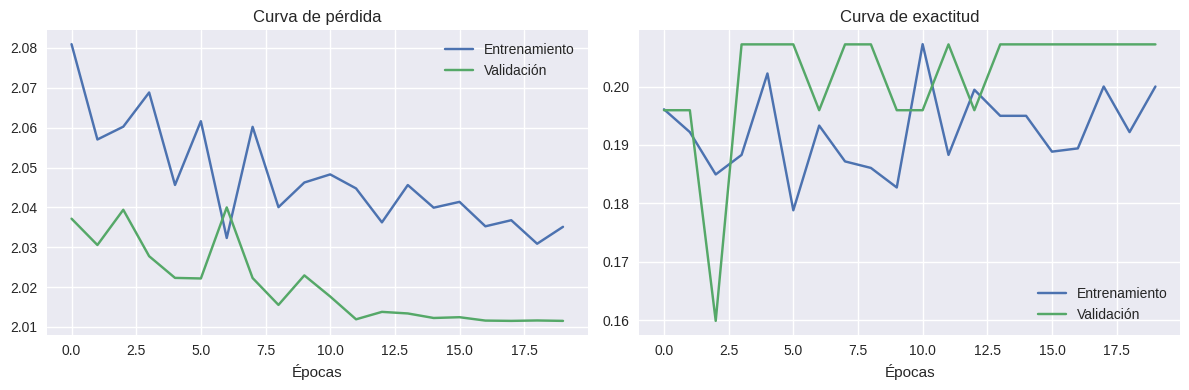

In [ ]:
if history:
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(hist['loss'], label='Entrenamiento')
    axes[0].plot(hist.get('val_loss', []), label='Validación')
    axes[0].set_title('Curva de pérdida')
    axes[0].set_xlabel('Épocas')

    axes[1].plot(hist.get('accuracy', []), label='Entrenamiento')
    axes[1].plot(hist.get('val_accuracy', []), label='Validación')
    axes[1].set_title('Curva de exactitud')
    axes[1].set_xlabel('Épocas')
    for ax in axes: ax.legend()
    plt.tight_layout()
else:
    print('No hay historial para graficar.')


## 8. Evaluación multiclase (Test)
- Accuracy, **Balanced Accuracy**, **Macro-F1**.
- Matriz de confusión y reporte por clase.


Resultados (test): loss, acc = [2.2603237628936768, 0.1355932205915451]
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step
Accuracy: 0.1356 | Balanced Acc: 0.1111 | Macro-F1: 0.0265
Reporte de clasificación:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.00      0.00      0.00        16
pigmented benign keratosis       0.14      1.00      0.24        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.14       118
                 macro avg       0.02      0.11      0.0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


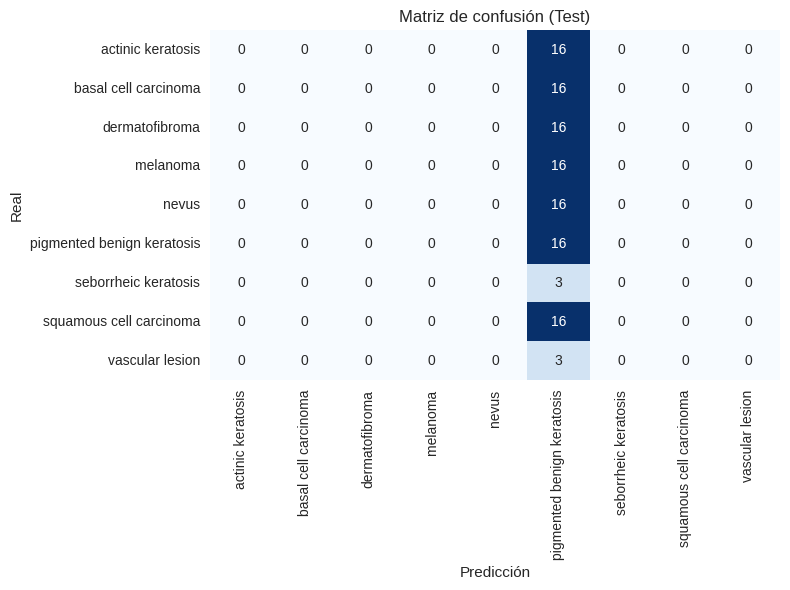

In [ ]:
 if test_gen:
    # Evaluación
    results = model.evaluate(test_gen, verbose=0)
    print('Resultados (test): loss, acc =', results)

    # Predicciones
    probs = model.predict(test_gen)
    y_pred = np.argmax(probs, axis=1)
    y_true = test_gen.classes
    target_names = list(test_gen.class_indices.keys())

    acc = (y_pred == y_true).mean()
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f'Accuracy: {acc:.4f} | Balanced Acc: {bal_acc:.4f} | Macro-F1: {macro_f1:.4f}')

    print('Reporte de clasificación:')
    print(classification_report(y_true, y_pred, target_names=target_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Matriz de confusión (Test)')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
else:
    print('Generador de test no configurado.')


## 9. Guardado del modelo


In [ ]:
model.save('modelo_skin_isic.h5')
print('Modelo guardado en modelo_skin_isic.h5')


Modelo guardado en modelo_skin_isic.h5


## 10. Fine-tuning (Opcional)
- Descongelar últimas capas del backbone y re-entrenar con LR bajo.


In [ ]:
# Ejemplo de fine-tuning sobre EfficientNet
# Descomenta para usar después de entrenamiento inicial
# for layer in efficient.layers[-30:]:
#     if not isinstance(layer, tf.keras.layers.BatchNormalization):
#         layer.trainable = True
# efficient.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
#                  loss='categorical_crossentropy', metrics=['accuracy'])
# history_ft = efficient.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=callbacks)


---
### Consideraciones éticas y técnicas
- Uso exclusivamente **académico**.
- Los datasets de lesiones cutáneas pueden tener **sesgos** de adquisición (iluminación, dispositivos, población).
- Reporta resultados con métricas **equilibradas** y discute limitaciones.
- Verifica licencias y atribución en la página del dataset.
